In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bangla-book-lemmatized-5500-csv/bangla_book_lemmatized_5500.csv
/kaggle/input/bangla-electronics-lemmatized-final-1-csv/bangla_electronics_lemmatized_final.csv
/kaggle/input/bangla-book-lemmatized-18001-csv/bangla_book_lemmatized_18001.csv
/kaggle/input/bangla-book-lemmatized-18002-csv/bangla_book_lemmatized_18002.csv
/kaggle/input/bangla-book-lemmatized-csv/bangla_book_lemmatized.csv
/kaggle/input/bangla-electronics-lemmatized-csv/bangla_electronics_lemmatized.csv
/kaggle/input/bangla-electronics-csv/bangla_electronics.csv


## Importing Libraries

In [2]:
import nltk
from nltk.tokenize import word_tokenize
import numpy as np
from collections import Counter
from nltk.probability import FreqDist
nltk.download('punkt')
import pandas as pd
import gensim
from gensim.parsing.preprocessing import remove_stopwords
from nltk.stem import PorterStemmer
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import remove_stopwords

import nltk
import re

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Importing the book data

In [3]:

file1 = "/kaggle/input/bangla-electronics-lemmatized-final-1-csv/bangla_electronics_lemmatized_final.csv"

df1 = pd.read_csv(file1, on_bad_lines='skip', low_memory=False)


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4330 entries, 0 to 4329
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   review_label          4330 non-null   int64 
 1   lemmatizedReviewText  4330 non-null   object
dtypes: int64(1), object(1)
memory usage: 67.8+ KB


In [5]:
df1.head()

,review_label,lemmatizedReviewText
0,1,"['অসাধারণ', 'ফোন', 'অনেক', 'পছন্দ', 'হয়েছে', ..."
1,0,"['ডেলিভারী', 'বা', 'প্রডাক্ট', 'নিয়ে', 'কোন', ..."
2,0,"['এখনো', 'ভালো', 'আছে', 'ভবিষ্যতে', 'কি', 'হবে..."
3,1,"['এই', 'বাজেট', 'এ', 'খুবই', 'ভালো', 'ফোন']"
4,1,"['অনেকদিন', 'ধরে', 'ফোন', 'কিনবো', 'বলে', 'ভাব..."


## Balancing the dataset

In [6]:

positive_reviews = df1[df1['review_label'] == 1 ].sample(n=820, replace=True)
negative_reviews = df1[df1['review_label'] ==  0 ].sample(n=820, replace=True)
df = pd.concat([positive_reviews, negative_reviews])

In [7]:
positive_count = df['review_label'].value_counts().get(1, 0)
negative_count = df['review_label'].value_counts().get(0, 0)

print("Number of positive reviews:", positive_count)
print("Number of negative reviews:", negative_count)

Number of positive reviews: 820
Number of negative reviews: 820


In [8]:
df.reset_index(drop=True, inplace=True)

In [9]:
df.head()

,review_label,lemmatizedReviewText
0,1,"['প্রডাক্ট', 'প্রায়', 'দিন', 'করে', 'ভালো', 'এ..."
1,1,"['বিল্ড', 'কোয়ালিটি', 'বেশ', 'ভাল', 'স্পিড', '..."
2,1,"['এফোরটেক', 'এর', 'কিবোর্ড', 'সবচেয়ে', 'সুবিধা..."
3,1,"['যেমন', 'টা', 'চেয়েছি', 'ঠিক', 'তেমনটা', 'পেয়..."
4,1,"['এত', 'কম', 'দামের', 'থেকে', 'ভালো', 'পণ্য', ..."


## Vocabulary Creation

In [10]:
import ast
wordList = []
vocabulary = set()

for review_text in df['lemmatizedReviewText']:
    try:
        words = ast.literal_eval(review_text)
        
    except ValueError:
        print(f"Skipping invalid list: {review_text}")
        continue
    
    wordList.extend(words)  
    vocabulary.update(words) 

print("Total number of words in wordList:", len(wordList))
print("Total number of unique words in vocabulary:", len(vocabulary))


Total number of words in wordList: 37984
Total number of unique words in vocabulary: 4830


In [11]:
vocabsize= len(vocabulary)


In [12]:
word_2_int={}
int_2_word={}

## Integer to word  and word to integer mapping

In [13]:
wordList = list(vocabulary)  
print("Number of words in wordList:", len(wordList))
word_2_int={}
int_2_word={}
for i, word in enumerate(wordList):
    
    word_2_int[word] = i  
    int_2_word[i] = word

print("Number of words in word2int:", len(word_2_int))
print("Number of indices in int2word:", len(int_2_word))

Number of words in wordList: 4830
Number of words in word2int: 4830
Number of indices in int2word: 4830


## Context Window Pair

In [14]:
def get_windows(words, C):
    
    i = C
    while i < len(words) - C:
        center_word = words[i]
        context_words = words[(i - C):i] + words[(i + 1):(i + C + 1)]
        yield context_words, center_word
        i += 1

C=1

In [15]:
context_data = []
senti_data = []
center_data=[]
i = 0
for index, row in df.iterrows():
    
    words = ast.literal_eval(row['lemmatizedReviewText'])

    sentiment_label = row['review_label']
   

    for context_words, center_word  in get_windows(words, C):
        context_data.append(context_words)
        senti_data.append(sentiment_label)
        center_data.append(center_word)
    i=i+1
print("Context Words:",context_data[2])
print("Target Words:",center_data[2])
print("Sentiment_label:",senti_data[2])

Context Words: ['দিন', 'ভালো']
Target Words: করে
Sentiment_label: 1


## Function to one hot encoding

In [ ]:
X_test.info()

In [16]:
def to_one_hot(data_point_index, vocabsize):
    temp = np.zeros(vocabsize)
    temp[data_point_index] = 1
    return temp

In [17]:
context_data_hot = []

center_data_hot=[]

i=0

for context_word,center_word in zip(context_data,center_data):
    
    
    
    context_words_vectors = [to_one_hot(word_2_int[w], vocabsize) for w in context_word]
    context_data_hot.append(np.mean(context_words_vectors,axis=0))
    center_data_hot.append(to_one_hot(word_2_int[center_word], vocabsize))
    
    i=i+1
print(len( context_words_vectors ))
print(context_data_hot[0])

2
[0. 0. 0. ... 0. 0. 0.]


## Batch creation


In [18]:
def get_batches(batch_size):
    batch_x = []
    batch_y = []
    batch_senti=[]
    for x, y,z in zip ( context_data_hot,center_data_hot,senti_data):
        while len(batch_x) < batch_size:
            batch_x.append(x)
            batch_y.append(y)
            batch_senti.append(z)
        else:
            yield np.array(batch_x).T, np.array(batch_y).T,np.array(batch_senti).T
            batch = []

## Sigmoid Function

In [19]:

def sigmoid(z):
   
    return 1.0/(1.0+np.exp(-z))

## Initialize Values

In [20]:
def initialize_model(N,V,sentiment_classes, random_seed=1):
   
    np.random.seed(random_seed)

    W1 = np.random.rand(N,V)
   
    W2 = np.random.rand(V,N)
   
    b1 = np.random.rand(N,1)
   
    b2 = np.random.rand(V,1)

    W_s = np.random.rand(1, N)  
    b_s = np.random.rand(1, 1)
   

    return W1, W2, b1, b2,W_s,b_s

## Softmax

In [21]:
def softmax(z):
   
    e_z = np.exp(z)
    yhat = e_z/np.sum(e_z,axis=0)
  
    
    return yhat

## Forward Propagation

In [22]:
def forward_prop(x, W1, W2, b1, b2,W_sentiment,b_sentiment):

    
    h = np.dot(W1,x)+b1
    h = np.maximum(0,h)
    z = np.dot(W2,h)+b2
    return z, h 

## Cost while learining target word

In [23]:
def compute_cost(y, yhat, batch_size):
    logprobs = np.multiply(np.log(yhat),y) + np.multiply(np.log(1 - yhat), 1 - y)
    cost = - 1/batch_size * np.sum(logprobs)
    cost = np.squeeze(cost)
    return cost

## Cost while predicting  sentiment

In [24]:
def compute_sentiment_cost(y_sentiment, pred_s, batch_size):
   epsilon = 1e-7 
   cost_s = -1 / batch_size * np.sum(y_sentiment * np.log(pred_s + epsilon) + (1 - y_sentiment) * np.log(1 - pred_s + epsilon))

   cost_s = np.squeeze(cost_s)
   return cost_s

## BackPropagation function

In [25]:
def back_prop(x, yhat, y, h, W1, W2, b1, b2, W_s,b_s, pred_s,y_sentiment, batch_size):
    l1 = np.dot(W2.T, (yhat - y))
    l1 = np.maximum(0, l1)
    grad_W1 = np.dot(l1, x.T) / batch_size
    grad_W2 = np.dot(yhat - y, h.T) / batch_size
    grad_b1 = np.sum(l1, axis=1, keepdims=True) / batch_size
    grad_b2 = np.sum(yhat - y, axis=1, keepdims=True) / batch_size
    ds = pred_s - y_sentiment
    grad_W_s = np.dot(ds, h.T) / batch_size
    grad_b_s = np.sum(ds, axis=1, keepdims=True) / batch_size
   
    
    return grad_W1, grad_W2, grad_b1, grad_b2, grad_W_s, grad_b_s

## Sentiment Prediction Model

In [26]:
def sentiment_prediction_model(W_s, b_s, h):
    z_s = np.dot(W_s, h) + b_s
    pred_s = sigmoid(z_s)
    return pred_s

In [27]:
iterations = []
cost_values = []

## Gradient Descent

In [28]:
def gradient_descent(N, V, num_iters, alpha=0.1,beta=0.05):
    sentiment_classes = 2

    W1, W2, b1, b2 ,W_s,b_s= initialize_model(N,V,1,random_seed = 282)
    batch_size = 68
    iters = 0
    
  
    for x, y ,y_sentiment in get_batches(batch_size): 
        
        y_sentiment = y_sentiment.reshape(1, -1)
        
      
        z, h  = forward_prop(x, W1, W2, b1, b2,W_s,b_s)
        pred_s= sentiment_prediction_model(W_s, b_s, h)
        

        
        yhat = softmax(z)
        
        cost = compute_cost(y, yhat, batch_size)
        sentiment_loss = compute_sentiment_cost(y_sentiment,pred_s, batch_size)  # y_sentiment are the true sentiment labels
        total_loss = beta * cost + (1 - beta) * sentiment_loss

        
        if ( (iters+1) % 10 == 0):
            iterations.append(iters + 1)
            cost_values.append(total_loss)
            print(f"iters: {iters + 1} cost: {total_loss:.6f}")
        
        grad_W1, grad_W2, grad_b1, grad_b2,grad_W_s, grad_b_s = back_prop(x, yhat, y, h, W1, W2, b1, b2, W_s,b_s, pred_s,y_sentiment, batch_size)
        
        
        W1 -= alpha*grad_W1 
        W2 -= alpha*grad_W2
        b1 -= alpha*grad_b1
        b2 -= alpha*grad_b2

     # Updating sentiment model parameters
        W_s -= alpha * grad_W_s
        b_s -= alpha * grad_b_s
        
        
        
        iters += 1 
        if iters == num_iters: 
            break
        if iters % 100 == 0:
            
            alpha *= 0.66
        loss_P = total_loss
            
    return W1, W2, b1, b2 , loss_P

In [29]:
N = 100
W1, W2, b1, b2 ,W_s,b_s= initialize_model(N,vocabsize, 3,random_seed = 282)

num_iters = 150

W1, W2, b1, b2 ,loss_p = gradient_descent(N,vocabsize,num_iters)

iters: 10 cost: 0.000908
iters: 20 cost: 0.000460
iters: 30 cost: 0.000309
iters: 40 cost: 0.000233
iters: 50 cost: 0.000188
iters: 60 cost: 0.000157
iters: 70 cost: 0.000135
iters: 80 cost: 0.000118
iters: 90 cost: 0.000105
iters: 100 cost: 0.000095
iters: 110 cost: 0.000089
iters: 120 cost: 0.000084
iters: 130 cost: 0.000079
iters: 140 cost: 0.000075
iters: 150 cost: 0.000071


In [30]:
print(len(cost_values))

15


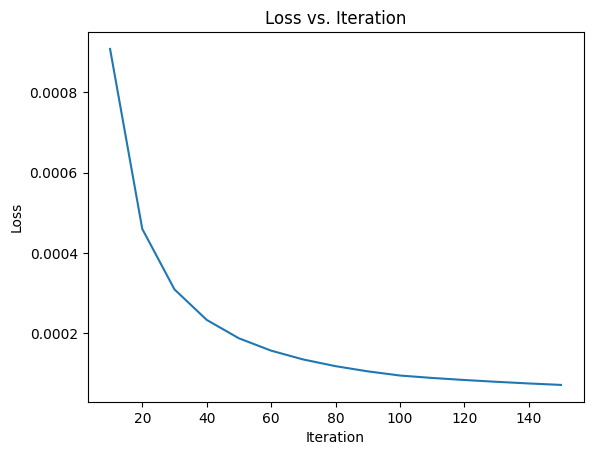

<Figure size 300x200 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [31]:
import matplotlib.pyplot as plt

plt.plot(iterations, cost_values)

# Add labels and title
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs. Iteration')
plt.figure(figsize=(3, 2))  # Adjust width and height as needed

# Show the plot
plt.show()
plt.savefig('loss_algo1_p.png', dpi=300)  # Save as PNG format with high resolution (300 dpi)


In [32]:
import numpy as np
import ast

def vectorize_text(text, word_to_index, embedding_matrix):
    try:
        words = ast.literal_eval(text)
    except ValueError as e:
        print(f"Error parsing text: {text}. Error: {e}")
        return np.zeros(embedding_matrix.shape[0])
    
    vectors = [embedding_matrix[:, word_to_index[word]] for word in words if word in word_to_index]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(embedding_matrix.shape[0])

In [33]:
embds = W1.T+W2

In [34]:
embds=embds/2.0

In [35]:
print(embds.T.shape)

(100, 4830)


In [36]:
X = np.array([vectorize_text(text, word_2_int, embds.T) for text in df['lemmatizedReviewText']])
print(X.shape)

(1640, 100)


In [37]:
y = np.array(df['review_label'])

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [40]:
model = LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [41]:

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_mat)

class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)

Accuracy: 0.7987804878048781
Confusion Matrix:
 [[142  22]
 [ 44 120]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.87      0.81       164
           1       0.85      0.73      0.78       164

    accuracy                           0.80       328
   macro avg       0.80      0.80      0.80       328
weighted avg       0.80      0.80      0.80       328



In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [43]:

param_grid = {
    'n_estimators': [100,150, 200, 250],  
    'max_depth': [5,10, 15, None],      
    'min_samples_split': [ 5,8, 10],  
    'min_samples_leaf': [3,4,5 ]     
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=100; total time=   1.0s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=150; total time=   1.5s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=200; total time=   2.1s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=250; total time=   2.5s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=250; total time=   2.4s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=8, n_estimators=150; total time=   1.5s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=8, n_estimators=150; total time=   1.5s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=8, n_estimators=200; total time=   2.7s
[CV] END max_depth=5, min_samples_leaf=3, min_samples_split=8, n_estimators=250; total time=   2.4s
[CV] END max_depth=5, min_samples_lea

In [48]:
rf = RandomForestClassifier(max_depth=10, min_samples_leaf=3, min_samples_split=10,
                       n_estimators=150, random_state=42)


[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=5, n_estimators=150; total time=   2.2s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=5, n_estimators=200; total time=   2.6s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=5, n_estimators=250; total time=   3.0s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=8, n_estimators=100; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=8, n_estimators=150; total time=   1.8s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=8, n_estimators=150; total time=   1.8s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=8, n_estimators=200; total time=   2.4s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=8, n_estimators=250; total time=   2.9s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=5, min_samples_split=10, n_est

In [49]:
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, min_samples_split=10,
                       n_estimators=150, random_state=42)

In [50]:
y_pred_rf =rf.predict(X_test)

In [51]:
accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)


confusion_mat = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", confusion_mat)


class_report = classification_report(y_test, y_pred_rf)
print("Classification Report:\n", class_report)

Accuracy: 0.8475609756097561
Confusion Matrix:
 [[141  23]
 [ 27 137]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       164
           1       0.86      0.84      0.85       164

    accuracy                           0.85       328
   macro avg       0.85      0.85      0.85       328
weighted avg       0.85      0.85      0.85       328



In [52]:
import seaborn as sns


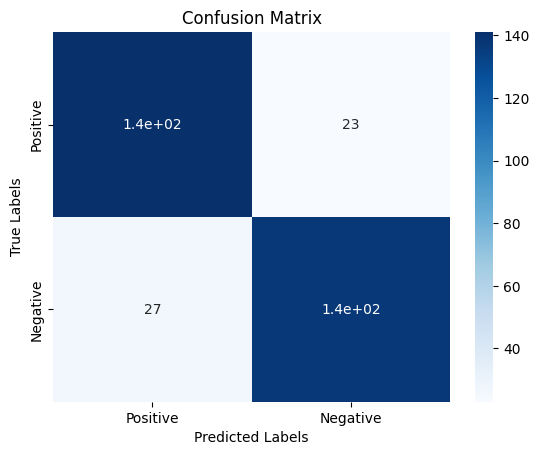

<Figure size 640x480 with 0 Axes>

In [53]:
labels = ['Positive', 'Negative']
sns.heatmap(confusion_mat, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
plt.savefig('confusion_matrix_algo1.png', dpi=300)  


In [54]:
embds = W1.T+W2

In [55]:
embds=embds/2.0

In [56]:
def review_to_vector1(review, model):
    word_vectors=[]
    for word in review:
        if (word in word_2_int):
             
             word_vectors.append(model[word_2_int[word]] )
    
  
    if len(word_vectors) == 0:
        return np.zeros(model.shape[0])
    else:
        return np.mean(word_vectors, axis=0)

In [74]:
def predict_sentiment(sentence):
    
    sentence_vector = review_to_vector1(sentence, embds).reshape(1, -1)  
  
    prediction = rf.predict(sentence_vector)
    
    
    sentiment = "Positive" if prediction[0] == 1 else "Negative"
    return sentiment

In [75]:
input_sentence = ['এই', 'বাজেট', 'এ', 'ভারী', 'ভালো', 'ফোন ']
print(predict_sentiment(input_sentence))

Positive


In [77]:
input_sentence = ['ডেলিভারী',  'নিয়ে', 'কোন', 'কথা', 'নেই', 'বেশ', 'ভালো', 'কিন্তু', 'ফোন', 'ভালো', 'না']

print(predict_sentiment(input_sentence))

Negative


## Algorithm2

In [78]:
file2 = "/kaggle/input/bangla-book-lemmatized-18002-csv/bangla_book_lemmatized_18002.csv"
book = pd.read_csv(file2, on_bad_lines='skip', low_memory=False)


In [80]:
book.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   review_label          5000 non-null   int64 
 1   count                 5000 non-null   int64 
 2   lemmatizedReviewText  5000 non-null   object
dtypes: int64(2), object(1)
memory usage: 117.3+ KB


In [81]:
book.head()

,review_label,count,lemmatizedReviewText
0,1,23,"['ডেটা', 'স্ট্রাকচার', 'অ্যালগরিদম', 'শিখতে', ..."
1,1,21,"['ফিলোসোফি', 'দর্শন', 'সম্পর্কে', 'জ্ঞান', 'লা..."
2,1,17,"['বইটা', 'নিসন্দেহে', 'ভালো', 'মূল্যের', 'দিক'..."
3,1,24,"['যেটুকু', 'পড়লাম', 'মুগ্ধ', 'গেছি', 'ব্রেইন',..."
4,1,11,"['কলেজ', 'থাকতে', 'কিনসিলাম', 'বুট', 'কলেজ', '..."


In [82]:
df2=book

In [83]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   review_label          5000 non-null   int64 
 1   count                 5000 non-null   int64 
 2   lemmatizedReviewText  5000 non-null   object
dtypes: int64(2), object(1)
memory usage: 117.3+ KB


In [84]:
import ast
wordList_df2 = []
vocab_df2 = set()

for review_text in df2['lemmatizedReviewText']:
    try:
        words = ast.literal_eval(review_text)
        
    except ValueError:
        print(f"Skipping invalid list: {review_text}")
        continue
    
    wordList_df2.extend(words)  
    vocab_df2.update(words)  
print("Total number of words in wordList:", len(wordList_df2))
print("Total number of unique words in vocabulary:", len(vocab_df2))

Total number of words in wordList: 93613
Total number of unique words in vocabulary: 22973


In [85]:
vocab_df1= vocabulary
vocabsize_df2 = len(vocab_df2)

In [86]:
wordList = list(vocab_df2) 
print("Number of words in wordList:", len(wordList))
word_2_int_df2={}
int_2_word_df2={}
for i, word in enumerate(wordList):
    word_2_int_df2[word] = i  
    int_2_word_df2[i] = word

print("Number of words in word2int:", len(word_2_int_df2))
print("Number of indices in int2word:", len(int_2_word_df2))

Number of words in wordList: 22973
Number of words in word2int: 22973
Number of indices in int2word: 22973


In [87]:
def load_word_embeddings_word(W1,W2, vocabulary):
    embs = (W1.T + W2)/2.0
    vocab_size = len(vocabulary)  
    embeddings = {}  
    for idx, word in enumerate(vocabulary):
        
        word_embedding = embs[idx,:]

        embeddings[word] = word_embedding

    return embeddings

In [88]:
word_embeddings = load_word_embeddings_word(W1,W2,vocabulary)


## Now Doing The Frequency Distribution

In [89]:
def load_corpus_frequency(domain):
    
    all_words = []
    
    
    for review_text in domain['lemmatizedReviewText']:
        try:
            words = ast.literal_eval(review_text)
            
            all_words.extend(words)
        except ValueError as e:
            print(f"Skipping invalid list: {review_text}. Error: {e}")
    
    fdist = nltk.FreqDist(all_words)
    
    return fdist

In [90]:
freq_P= load_corpus_frequency(df)
freq_Q = load_corpus_frequency(df2)

In [91]:
print(len(freq_P))
print(len(freq_Q))

4830
22973


## Finding The common words in both domains

In [92]:
def common_words(domain1_words, domain2_words):
    
    
    domain1_set = set(domain1_words)
    domain2_set = set(domain2_words)

    common_set = domain2_set.intersection(domain1_set)

    common_words_list = list(common_set)

    return common_words_list

In [93]:
common_words_list = common_words(vocabulary,vocab_df2)


In [94]:
print(len(common_words_list))

2140


In [95]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [96]:
def get_kth_most_common_word_frequency(frequency_list,k):
    
    freq_dist = frequency_list
    

    
    kth_most_common_word_frequency = freq_dist.most_common(k)[-1][1]
    
    return kth_most_common_word_frequency

In [97]:
def get_kth_most_common_word_frequency1(corpus_freq, k):
    sorted_freq = sorted(corpus_freq.values(), reverse=True)
    return sorted_freq[k-1] if k <= len(sorted_freq) else 0

def freq_occur_standardization1(word, corpus_freq):
    
    k = 10  
    kth_freq = get_kth_most_common_word_frequency1(corpus_freq, k)
    return corpus_freq.get(word, 0) / kth_freq if kth_freq > 0 else 0

def domain_relevance1(w, freq_P, freq_Q):
    # using the Sørensen-Dice coefficient.
    standard_freq_P = freq_occur_standardization1(w, freq_P)
    standard_freq_Q = freq_occur_standardization1(w, freq_Q)
    sum_standard_freq = standard_freq_P + standard_freq_Q
    return (2 * standard_freq_P * standard_freq_Q / sum_standard_freq) if sum_standard_freq > 0 else 0

## Frequency of occurrence of the words after standardization


In [98]:
def freq_occur_standardization(word,corpus_freq):
    k=10
    freq_occurrence_standardization = corpus_freq[word] / get_kth_most_common_word_frequency(corpus_freq, k)
    return freq_occurrence_standardization

# Domain relevance function using Sørensen-Dice coefficient


In [99]:
def domain_relevance(w, freq_P, freq_Q):
    a=( freq_occur_standardization(w,freq_P) +  freq_occur_standardization(w,freq_Q))
    
    
    return 2 * freq_occur_standardization(w,freq_P) * freq_occur_standardization(w,freq_Q) / a

# Information transfer function


In [100]:
def information_transfer(phi_w, lambda_):
    return sigmoid(lambda_ * phi_w)

In [101]:

def compute_loss(W_p, W_q, L, freq_P, freq_Q, lambda_):
    loss_Q = 0 
    for w in L:
        idx_p = word_2_int[word]
        idx_q = word_2_int_df2[word]
        phi_w = domain_relevance(w, freq_P, freq_Q)
        t_w = information_transfer(phi_w, lambda_)
        loss_Q += t_w * np.linalg.norm(W_p[idx_p] - W_q[idx_q])**2
    return loss_Q

In [102]:

learning_rate = 1.0
lambda_ = 0.7  
epochs = 20    

In [103]:
embs = (W1.T + W2)/2.0

In [104]:

W_s = embs  


W_q = np.random.rand(vocabsize_df2, N)

L = common_words_list 
print(len(L))
print(len(common_words_list))

2140
2140


In [105]:
import tensorflow as tf


2024-03-18 07:22:15.478744: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-18 07:22:15.478974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-18 07:22:15.691071: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [106]:
W_q_t= tf.Variable(tf.random.normal((vocabsize_df2,N)))


In [107]:
optimizer = tf.optimizers.SGD(learning_rate=learning_rate)


In [108]:
W_p = embs

In [109]:
i=[]
c=[]

In [110]:
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss_Q = loss_p  
        for word in L:
            #print(word)
            idx_p = word_2_int[word] 
            idx_q =word_2_int_df2[word]

            phi_w = domain_relevance(word, freq_P, freq_Q)
            t_w = information_transfer(phi_w, lambda_)
            #print(idx_q)
            loss_Q += t_w * tf.reduce_sum(tf.square(W_p[idx_p] - W_q_t[idx_q]))
            

    gradients = tape.gradient(loss_Q, [W_q_t])

    optimizer.apply_gradients(zip(gradients, [W_q_t]))

    print(f'Epoch {epoch}, Loss: {loss_Q.numpy()}')
    i.append(epoch)
    c.append(loss_Q)

Epoch 0, Loss: 138981.34375
Epoch 1, Loss: 180.0004119873047
Epoch 2, Loss: 72.12066650390625
Epoch 3, Loss: 39.56721496582031
Epoch 4, Loss: 22.3060302734375
Epoch 5, Loss: 12.644840240478516
Epoch 6, Loss: 7.181699752807617
Epoch 7, Loss: 4.083275318145752
Epoch 8, Loss: 2.323641300201416
Epoch 9, Loss: 1.323378324508667
Epoch 10, Loss: 0.7543029189109802
Epoch 11, Loss: 0.43028151988983154
Epoch 12, Loss: 0.24564480781555176
Epoch 13, Loss: 0.14035281538963318
Epoch 14, Loss: 0.08026313781738281
Epoch 15, Loss: 0.045944999903440475
Epoch 16, Loss: 0.026331249624490738
Epoch 17, Loss: 0.015113584697246552
Epoch 18, Loss: 0.008693475276231766
Epoch 19, Loss: 0.005016662180423737


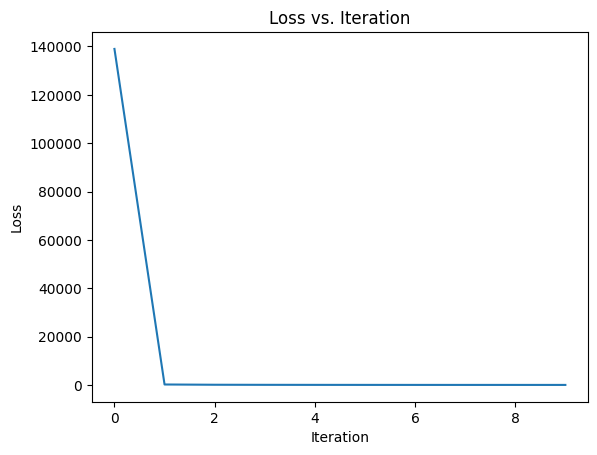

<Figure size 640x480 with 0 Axes>

In [111]:
import matplotlib.pyplot as plt

plt.plot(i[:10], c[:10])

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs. Iteration')

plt.show()
plt.savefig('loss_algo1.png', dpi=300)  


In [112]:
w=W_q_t.numpy()

In [113]:
X_df = np.array([vectorize_text(text,  word_2_int_df2, w.T) for text in df2['lemmatizedReviewText']])
print(X_df.shape)

(5000, 100)


In [114]:
y_df= np.array(df2['review_label'])

In [115]:
from sklearn.model_selection import train_test_split

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size=0.1, stratify=y_df, random_state=42)

In [116]:
model_df = LogisticRegression(class_weight='balanced',max_iter=1000)
model_df.fit(X_train_df, y_train_df)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [117]:

y_pred_df= model.predict(X_test_df)

# Accuracy
accuracy = accuracy_score(y_test_df, y_pred_df)
print("Accuracy:", accuracy)

# Confusion Matrix
confusion_mat = confusion_matrix(y_test_df, y_pred_df)
print("Confusion Matrix:\n", confusion_mat)

# Classification Report
class_report = classification_report(y_test_df, y_pred_df)
print("Classification Report:\n", class_report)

Accuracy: 0.564
Confusion Matrix:
 [[ 62 188]
 [ 30 220]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.25      0.36       250
           1       0.54      0.88      0.67       250

    accuracy                           0.56       500
   macro avg       0.61      0.56      0.52       500
weighted avg       0.61      0.56      0.52       500



In [118]:
rf_df = RandomForestClassifier(max_depth=20, min_samples_leaf=3, min_samples_split=5,
                       n_estimators=150, random_state=42)

In [119]:
rf_df.fit(X_train_df,y_train_df)

RandomForestClassifier(max_depth=20, min_samples_leaf=3, min_samples_split=5,
                       n_estimators=150, random_state=42)

In [120]:
y_pred_rf_df =rf.predict(X_test_df)

In [121]:

accuracy = accuracy_score(y_test_df, y_pred_rf_df)
print("Accuracy:", accuracy)

# Confusion Matrix
confusion_mat = confusion_matrix(y_test_df,y_pred_rf_df)
print("Confusion Matrix:\n", confusion_mat)

# Classification Report
class_report = classification_report(y_test_df, y_pred_rf_df)
print("Classification Report:\n", class_report)

Accuracy: 0.508
Confusion Matrix:
 [[ 23 227]
 [ 19 231]]
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.09      0.16       250
           1       0.50      0.92      0.65       250

    accuracy                           0.51       500
   macro avg       0.53      0.51      0.41       500
weighted avg       0.53      0.51      0.41       500



In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
labels = ['Positive', 'Negative']


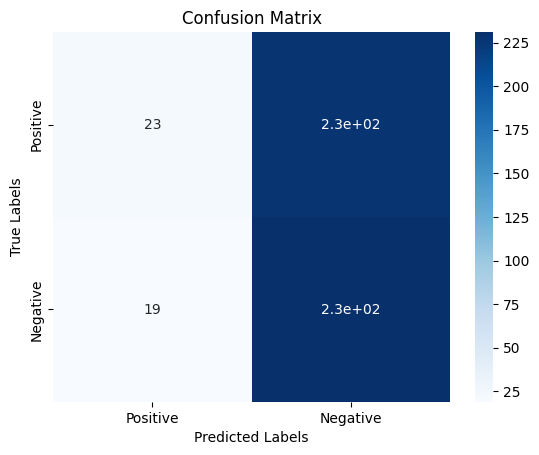

<Figure size 640x480 with 0 Axes>

In [124]:
sns.heatmap(confusion_mat, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
plt.savefig('confusion_matrix_algo_2.png', dpi=300)  # Save as PNG format with high resolution (300 dpi)
